## 3.3 Task: Multi-class Classification Modeling

In this task, we built a multi-class classification model to predict categorical outcomes in the e-commerce dataset. According to the project requirements, the model should classify transactional events such as `delivery_status` and `customer_segment` using the available input features.

We used Softmax Regression, implemented through Scikit-learn's `LogisticRegression` with `multi_class="multinomial"`. This model outputs probabilities for each class and predicts the class with the highest probability by default.

This task includes:
- preparing classification datasets
- building a preprocessing + classification pipeline
- training a Softmax Regression model
- evaluating classification performance
- analyzing class imbalance
- experimenting with decision thresholds
- interpreting confusion matrices in a business context

In [1]:
print("Task 3.3 - Multi-class Classification Modeling")

Task 3.3 - Multi-class Classification Modeling


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/cleaned_data.csv")
df.head()

,product_id,category,price,quantity,order_date,shipping_date,delivery_status,payment_method,device_type,channel,shipping_address,billing_address,customer_segment,order_month,order_day,shipping_time
0,845,Books,45.95,4,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,PayPal,Mobile,Paid Search,"976 Kevin Station, Davidmouth, Hawaii 92563","38182 Ariel Expressway, Campbellland, Oklahoma...",VIP,4,20,7
1,995,Electronics,403.17,3,2024-04-20 14:59:58.897063,2024-04-22 14:59:58.897063,Delivered,PayPal,Mobile,Paid Search,"72166 Cunningham Crescent, East Nicholasside, ...","38199 Edwin Plain, Johnborough, Maine 81826",Returning,4,20,2
2,997,Beauty,317.45,2,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,Credit Card,Mobile,Email,"2446 Johnson Junctions, Lynchtown, Minnesota 7...","58086 Smith Stream Suite 994, Lake Pamelabury,...",Returning,4,20,7
3,385,Home,24.08,3,2024-04-20 14:59:58.897063,2024-04-24 14:59:58.897063,Shipped,PayPal,Tablet,Social,"3113 Jessica Knolls, North Joshuafort, Alabama...","484 Palmer Harbors Apt. 866, Dustintown, Nebra...",VIP,4,20,4
4,31,Clothing,494.90,1,2024-04-20 14:59:58.897063,2024-04-25 14:59:58.897063,Delivered,PayPal,Tablet,Organic,"58196 Burgess Heights Suite 315, Douglasland, ...","67094 Schaefer Villages Suite 369, Douglasches...",VIP,4,20,5


delivery_status
Delivered    7047
Shipped      1938
Pending       513
Returned      502
Name: count, dtype: int64
delivery_status
Delivered    70.47
Shipped      19.38
Pending       5.13
Returned      5.02
Name: proportion, dtype: float64


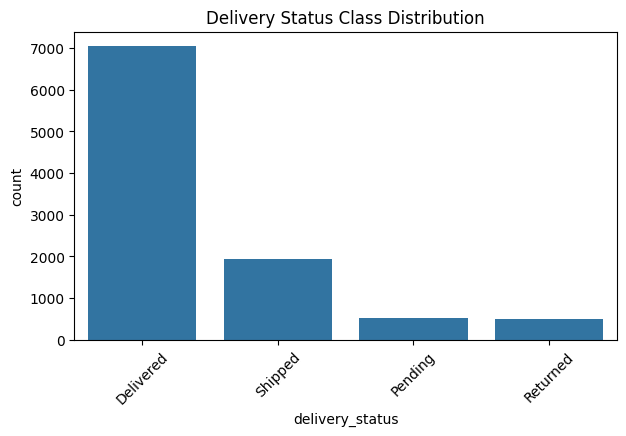

In [3]:
# Define features and target
y_status = df["delivery_status"]

X_status = df.drop(columns=["delivery_status", "customer_segment", "price"], errors="ignore")
X_status.head()

# Check class distribution
status_distribution = y_status.value_counts()
status_percent = y_status.value_counts(normalize=True) * 100

print(status_distribution)
print(status_percent)

plt.figure(figsize=(7, 4))
sns.countplot(x=y_status, order=y_status.value_counts().index)
plt.title("Delivery Status Class Distribution")
plt.xticks(rotation=45)
plt.show()

### Class Imbalance Observation
The `delivery_status` target is imbalanced, with the `Delivered` class appearing much more frequently than `Pending` or `Returned`. This is important because a classifier may achieve high overall accuracy by mostly predicting the majority class, while still performing poorly on rare but business-critical classes such as `Returned`.

In [5]:
# Identify column types

categorical_cols = X_status.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = [col for col in X_status.columns if col not in categorical_cols]

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)


# Build preprocessing pipeline
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# Train-test split with stratification
from sklearn.model_selection import train_test_split

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_status,
    y_status,
    test_size=0.2,
    random_state=42,
    stratify=y_status
)

print("Training samples:", X_train_s.shape[0])
print("Testing samples:", X_test_s.shape[0])

# Build Softmax Regression model
from sklearn.linear_model import LogisticRegression

status_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        # multi_class="multinomial",
        solver="lbfgs",
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

Categorical columns: ['category', 'order_date', 'shipping_date', 'payment_method', 'device_type', 'channel', 'shipping_address', 'billing_address']
Numerical columns: ['product_id', 'quantity', 'order_month', 'order_day', 'shipping_time']
Training samples: 8000
Testing samples: 2000


In [6]:
# Train the model
status_model.fit(X_train_s, y_train_s)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [7]:
# Predictions and probabilities
y_pred_s = status_model.predict(X_test_s)
y_prob_s = status_model.predict_proba(X_test_s)

print("Predicted classes:", status_model.named_steps["classifier"].classes_)
print("Probability matrix shape:", y_prob_s.shape)

Predicted classes: ['Delivered' 'Pending' 'Returned' 'Shipped']
Probability matrix shape: (2000, 4)


Accuracy: 0.577

Classification Report:

              precision    recall  f1-score   support

   Delivered       0.70      0.77      0.73      1409
     Pending       0.05      0.04      0.04       103
    Returned       0.09      0.04      0.05       100
     Shipped       0.18      0.15      0.16       388

    accuracy                           0.58      2000
   macro avg       0.25      0.25      0.25      2000
weighted avg       0.54      0.58      0.55      2000



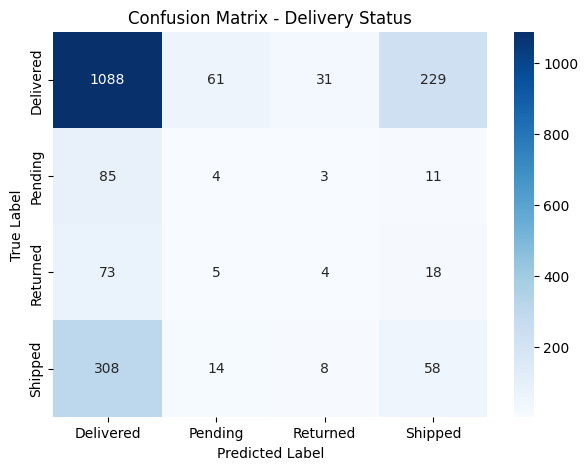

In [8]:
# Evaluate the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_s = accuracy_score(y_test_s, y_pred_s)
print("Accuracy:", accuracy_s)

print("\nClassification Report:\n")
print(classification_report(y_test_s, y_pred_s))

cm_s = confusion_matrix(y_test_s, y_pred_s, labels=status_model.named_steps["classifier"].classes_)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_s,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=status_model.named_steps["classifier"].classes_,
    yticklabels=status_model.named_steps["classifier"].classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Delivery Status")
plt.show()

In [9]:
# Cross-validation
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracy = cross_val_score(status_model, X_train_s, y_train_s, cv=cv, scoring="accuracy")
cv_f1_macro = cross_val_score(status_model, X_train_s, y_train_s, cv=cv, scoring="f1_macro")

print("CV Accuracy scores:", cv_accuracy)
print("Average CV Accuracy:", cv_accuracy.mean())

print("CV F1 Macro scores:", cv_f1_macro)
print("Average CV F1 Macro:", cv_f1_macro.mean())

CV Accuracy scores: [0.5525   0.574375 0.580625 0.5875   0.57625 ]
Average CV Accuracy: 0.5742499999999999
CV F1 Macro scores: [0.23646783 0.24916665 0.24395132 0.26521268 0.2549772 ]
Average CV F1 Macro: 0.24995513622627374


Class labels: ['Delivered' 'Pending' 'Returned' 'Shipped']
Classification Report After Threshold Adjustment:

              precision    recall  f1-score   support

   Delivered       0.70      0.66      0.68      1409
     Pending       0.04      0.03      0.03       103
    Returned       0.07      0.23      0.11       100
     Shipped       0.20      0.13      0.16       388

    accuracy                           0.51      2000
   macro avg       0.25      0.26      0.25      2000
weighted avg       0.54      0.51      0.52      2000



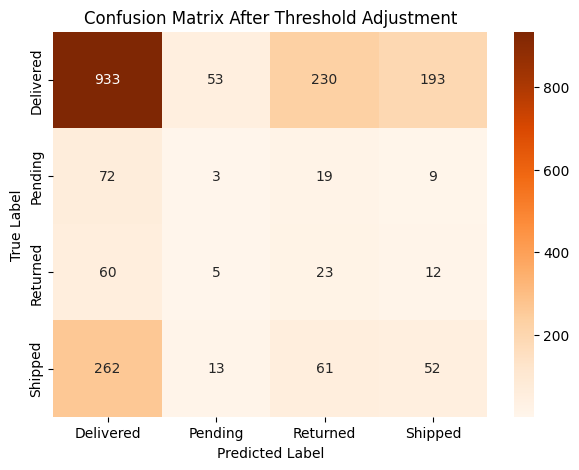

In [10]:
# Threshold adjustment for rare classes
class_labels = status_model.named_steps["classifier"].classes_
print("Class labels:", class_labels)

# manually adjust the threshold.
returned_index = list(class_labels).index("Returned")
returned_probs = y_prob_s[:, returned_index]

threshold = 0.20
adjusted_pred = []

for i in range(len(y_prob_s)):
    if returned_probs[i] >= threshold:
        adjusted_pred.append("Returned")
    else:
        adjusted_pred.append(class_labels[np.argmax(y_prob_s[i])])

adjusted_pred = np.array(adjusted_pred)

# evaluate
print("Classification Report After Threshold Adjustment:\n")
print(classification_report(y_test_s, adjusted_pred))

cm_adjusted = confusion_matrix(y_test_s, adjusted_pred, labels=class_labels)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_adjusted,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix After Threshold Adjustment")
plt.show()



In [11]:
# Compare default vs adjusted threshold
from sklearn.metrics import precision_score, recall_score, f1_score

default_precision = precision_score(y_test_s, y_pred_s, labels=["Returned"], average=None, zero_division=0)[0]
default_recall = recall_score(y_test_s, y_pred_s, labels=["Returned"], average=None, zero_division=0)[0]
default_f1 = f1_score(y_test_s, y_pred_s, labels=["Returned"], average=None, zero_division=0)[0]

adjusted_precision = precision_score(y_test_s, adjusted_pred, labels=["Returned"], average=None, zero_division=0)[0]
adjusted_recall = recall_score(y_test_s, adjusted_pred, labels=["Returned"], average=None, zero_division=0)[0]
adjusted_f1 = f1_score(y_test_s, adjusted_pred, labels=["Returned"], average=None, zero_division=0)[0]

comparison_df = pd.DataFrame({
    "Method": ["Default Threshold", "Adjusted Threshold"],
    "Returned Precision": [default_precision, adjusted_precision],
    "Returned Recall": [default_recall, adjusted_recall],
    "Returned F1": [default_f1, adjusted_f1]
})

comparison_df

,Method,Returned Precision,Returned Recall,Returned F1
0,Default Threshold,0.086957,0.04,0.054795
1,Adjusted Threshold,0.069069,0.23,0.106236


## Why Linear Regression Is Not Suitable for Classification

Linear regression predicts continuous numerical values, while classification requires assigning an input to one of several discrete categories. If linear regression were used for classification, it could produce outputs outside the valid range of class probabilities, such as negative values or values greater than 1. Therefore, it is not appropriate for categorical prediction tasks such as `delivery_status` or `customer_segment`.

## How Softmax Regression Works

Softmax Regression, also called Multinomial Logistic Regression, is used when the target variable has more than two classes. The model first computes a score for each class. These scores are then passed through the Softmax function, which converts them into probabilities that sum to 1.

For each input:
- the model gives a probability for each class
- the highest probability is normally chosen as the predicted class

This makes the model suitable for multi-class problems such as predicting `Delivered`, `Shipped`, `Pending`, or `Returned`.

## Log-Loss (Categorical Cross-Entropy)

Log-loss measures how different the predicted class probabilities are from the true class labels. A lower log-loss means the predicted probabilities are closer to the correct class.

This is useful because classification is not just about whether the final class is correct, but also about how confident the model is in its predictions. A model that assigns high probability to the wrong class receives a larger penalty.

## Business Meaning of Misclassification Errors

The confusion matrix shows how often the model predicts each class correctly or incorrectly.

In the AuraCart context:
- Predicting a `Returned` order as `Delivered` is risky because the business may fail to identify problematic orders early.
- Predicting `Pending` as `Shipped` may create incorrect expectations in logistics and customer communication.
- Predicting many orders as `Delivered` can inflate accuracy while hiding poor minority-class performance.

Therefore, evaluating only accuracy is not enough. Precision, recall, and F1-score are necessary to understand whether the model performs well for all classes, especially the important rare classes.

                    Predicting customer_segment

customer_segment
VIP          5149
Returning    4285
New           566
Name: count, dtype: int64
customer_segment
VIP          51.49
Returning    42.85
New           5.66
Name: proportion, dtype: float64


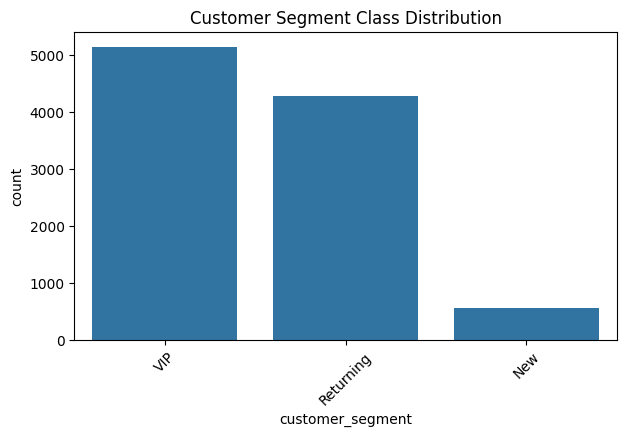

Categorical columns: ['category', 'order_date', 'shipping_date', 'payment_method', 'device_type', 'channel', 'shipping_address', 'billing_address']
Numerical columns: ['product_id', 'quantity', 'order_month', 'order_day', 'shipping_time']


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [13]:
# Define features and target for customer segment
y_segment = df["customer_segment"]

X_segment = df.drop(columns=["customer_segment", "delivery_status", "price"], errors="ignore")
X_segment.head()


# Check class distribution
segment_distribution = y_segment.value_counts()
segment_percent = y_segment.value_counts(normalize=True) * 100

print(segment_distribution)
print(segment_percent)

plt.figure(figsize=(7, 4))
sns.countplot(x=y_segment, order=y_segment.value_counts().index)
plt.title("Customer Segment Class Distribution")
plt.xticks(rotation=45)
plt.show()

# Identify column types
categorical_cols_seg = X_segment.select_dtypes(include=["object"]).columns.tolist()
numerical_cols_seg = [col for col in X_segment.columns if col not in categorical_cols_seg]

print("Categorical columns:", categorical_cols_seg)
print("Numerical columns:", numerical_cols_seg)

# Build preprocessing pipeline
preprocessor_seg = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_cols_seg),
    ("cat", categorical_transformer, categorical_cols_seg)
])

# Train-test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_segment,
    y_segment,
    test_size=0.2,
    random_state=42,
    stratify=y_segment
)

# Build and train Softmax model
segment_model = Pipeline([
    ("preprocessor", preprocessor_seg),
    ("classifier", LogisticRegression(
        # multi_class="multinomial",
        solver="lbfgs",
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

segment_model.fit(X_train_c, y_train_c)

Customer Segment Accuracy: 0.4515

Classification Report:

              precision    recall  f1-score   support

         New       0.09      0.04      0.06       113
   Returning       0.41      0.42      0.42       857
         VIP       0.50      0.52      0.51      1030

    accuracy                           0.45      2000
   macro avg       0.34      0.33      0.33      2000
weighted avg       0.44      0.45      0.44      2000



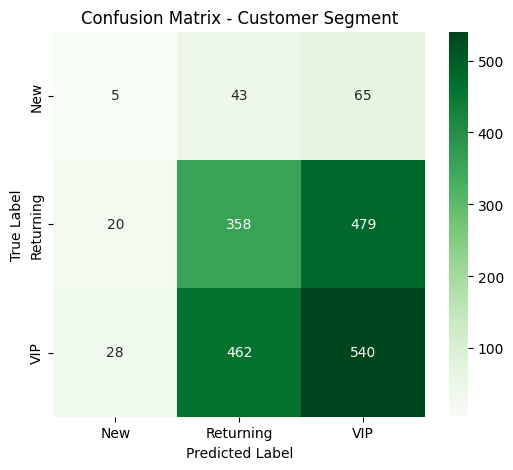

In [14]:
# Predict and evaluate
y_pred_c = segment_model.predict(X_test_c)
y_prob_c = segment_model.predict_proba(X_test_c)

accuracy_c = accuracy_score(y_test_c, y_pred_c)
print("Customer Segment Accuracy:", accuracy_c)

print("\nClassification Report:\n")
print(classification_report(y_test_c, y_pred_c))

cm_c = confusion_matrix(y_test_c, y_pred_c, labels=segment_model.named_steps["classifier"].classes_)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_c,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=segment_model.named_steps["classifier"].classes_,
    yticklabels=segment_model.named_steps["classifier"].classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Customer Segment")
plt.show()

In [15]:
# Cross-validation for customer segment model
cv_accuracy_c = cross_val_score(segment_model, X_train_c, y_train_c, cv=cv, scoring="accuracy")
cv_f1_macro_c = cross_val_score(segment_model, X_train_c, y_train_c, cv=cv, scoring="f1_macro")

print("Customer Segment CV Accuracy:", cv_accuracy_c)
print("Average CV Accuracy:", cv_accuracy_c.mean())

print("Customer Segment CV F1 Macro:", cv_f1_macro_c)
print("Average CV F1 Macro:", cv_f1_macro_c.mean())

Customer Segment CV Accuracy: [0.475    0.4425   0.466875 0.48875  0.465   ]
Average CV Accuracy: 0.46762499999999996
Customer Segment CV F1 Macro: [0.32776298 0.31704766 0.32661734 0.34044202 0.33302353]
Average CV F1 Macro: 0.3289787073822674


In [16]:
# Threshold adjustment for minority segment
segment_labels = segment_model.named_steps["classifier"].classes_
print("Segment labels:", segment_labels)

minority_class = "New"
minority_index = list(segment_labels).index(minority_class)
minority_probs = y_prob_c[:, minority_index]

threshold = 0.25
adjusted_segment_pred = []

for i in range(len(y_prob_c)):
    if minority_probs[i] >= threshold:
        adjusted_segment_pred.append(minority_class)
    else:
        adjusted_segment_pred.append(segment_labels[np.argmax(y_prob_c[i])])

adjusted_segment_pred = np.array(adjusted_segment_pred)

print("Customer Segment Report After Threshold Adjustment:\n")
print(classification_report(y_test_c, adjusted_segment_pred))

Segment labels: ['New' 'Returning' 'VIP']
Customer Segment Report After Threshold Adjustment:

              precision    recall  f1-score   support

         New       0.06      0.11      0.07       113
   Returning       0.41      0.39      0.40       857
         VIP       0.51      0.48      0.49      1030

    accuracy                           0.42      2000
   macro avg       0.32      0.33      0.32      2000
weighted avg       0.44      0.42      0.43      2000



In [18]:
# Save final customer segment model
import os
import joblib

# Create folder if it doesn't exist
os.makedirs("../artifacts", exist_ok=True)

# Save model
joblib.dump(segment_model, "../artifacts/customer_segment_model.joblib")

print("Customer segment model saved successfully.")

Customer segment model saved successfully.
